# How crude oil is sold to Europe

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/gasvaluechain/european_crude_oil_sales_foundation.ipynb)

**Refinery buyer, terminal/transporter, and producer perspectives with NeqSim**

This notebook follows one synthetic North Sea crude cargo from production allocation to
a European refinery. It connects benchmark pricing, quality differential, cargo quantity,
title and risk transfer, terminal and tanker logistics, provisional and final invoices,
refinery value, and producer netback. NeqSim supplies a reproducible crude characterization,
density, API gravity, vapour pressure, and broad boiling-range yields.

All commercial inputs are synthetic. This is not a current crude assessment, assay,
Incoterms interpretation, contract template, tax opinion, or trading recommendation.

## Learning outcomes

1. Separate physical custody, legal title, price exposure, and cash settlement.
2. Explain producer, terminal/pipeline, tanker, trader, and refinery-buyer roles.
3. Convert observed cargo volume to net standard quantity and mass.
4. Build a benchmark-plus-differential price and final invoice.
5. Relate crude quality and broad product yield to refinery willingness to pay.
6. Reconcile buyer delivered cost, logistics receipts, and producer netback.

## 1. One cargo, several linked records

| Record | Main content | Why it matters |
|---|---|---|
| Sale contract | parties, grade, quantity tolerance, pricing, delivery, credit | defines the bargain |
| Nomination and laycan | terminal window, vessel, loading rate | connects contract to logistics |
| Quantity certificate | observed volume, temperature, density, water and sediment | determines billable quantity |
| Quality certificate | API, sulfur, TAN, metals, salts, RVP, assay | determines acceptance and value |
| Bill of lading | shipped quantity and receipt | key cargo and title document |
| Pricing statement | benchmark quotation period and differential | determines unit price |
| Invoice | provisional payment and final true-up | closes cash settlement |

FOB, CFR, and CIF allocate delivery tasks, cost, and risk differently. The exact title
transfer can be separately drafted and must be read from the contract; it should never be
inferred from a simplified process diagram alone.

### Typical lifecycle

1. Producer forecasts an entitlement cargo and marketer offers a grade and laycan.
2. Buyer and seller agree benchmark, quotation period, differential, quality, and credit.
3. Terminal, pipeline, storage, inspector, and vessel are nominated.
4. Cargo is loaded; independent measurement and sampling produce certificates.
5. A provisional invoice uses estimated quantity and price.
6. The refinery receives, assays, schedules, and processes the crude.
7. Final benchmark average, quantity, quality claims, freight, and demurrage are settled.

## 2. Reproducible NeqSim Java `master` runtime

The next two cells build current NeqSim `master` in Colab and verify its commit, JAR hash,
and Java class source. They are shared with the gas-sales foundation notebook.

In [1]:
import hashlib
import os
import platform
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
os.environ.setdefault("NEQSIM_JVM_AUTOSTART", "false")

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "jpype1==1.7.1",
            "numpy",
            "pandas",
            "matplotlib",
            "scipy",
            "networkx",
        ],
        check=True,
    )
    source_root = Path("neqsim-java-master")
    if not source_root.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(source_root),
            ],
            check=True,
        )
    subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=source_root,
        check=True,
    )
    candidates = sorted((source_root / "target").glob("neqsim-*.jar"))
    candidates = [path for path in candidates if "original" not in path.name]
    if not candidates:
        raise FileNotFoundError("The NeqSim source build produced no runtime JAR.")
    NEQSIM_JAR = max(candidates, key=lambda path: path.stat().st_size).resolve()
else:
    source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-java-master"))
    source_jar = os.environ.get("NEQSIM_SOURCE_JAR", "")
    if not source_jar:
        raise RuntimeError("Set NEQSIM_SOURCE_JAR for local clean validation.")
    NEQSIM_JAR = Path(source_jar).resolve()

NEQSIM_COMMIT = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=source_root,
    text=True,
).strip()
NEQSIM_JAR_SHA256 = hashlib.sha256(NEQSIM_JAR.read_bytes()).hexdigest()
dependency_text = os.environ.get("NEQSIM_DEPENDENCY_JAR", "")
NEQSIM_DEPENDENCY_JARS = [
    Path(item).resolve()
    for item in dependency_text.split(os.pathsep)
    if item
]

print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_COMMIT}")
print(f"NeqSim source-built JAR: {NEQSIM_JAR}")
print(f"NeqSim JAR SHA-256: {NEQSIM_JAR_SHA256}")
print(f"Python: {platform.python_version()}")

NeqSim source ref: master
NeqSim source commit: 7ae08253b45180045a99a700314f23c9a7001b3c
NeqSim source-built JAR: /workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar
NeqSim JAR SHA-256: d1bdf734644537f2304d17e2e354008c48f189858a9055cc6c5aee11034344ba
Python: 3.12.13


In [2]:
import json
import math
from importlib import metadata

import jpype
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy
from IPython.display import display
from jpype import JClass
from matplotlib.patches import Patch
from scipy.optimize import linprog

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)

class_path = [str(NEQSIM_JAR)]
class_path.extend(str(path) for path in NEQSIM_DEPENDENCY_JARS)
if not jpype.isJVMStarted():
    # Direct JVM startup is the validated equivalent of jpype.addClassPath.
    jpype.startJVM(classpath=class_path)

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
StandardISO6976 = JClass(
    "neqsim.standards.gasquality.Standard_ISO6976_2016"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
class_source = str(
    SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
print(f"Loaded NeqSim class code source: {class_source}")
assert str(NEQSIM_JAR) in class_source

Loaded NeqSim class code source: file:/workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar


In [3]:
SystemPrEos = JClass("neqsim.thermo.system.SystemPrEos")
StandardD4052 = JClass(
    "neqsim.standards.oilquality.Standard_ASTM_D4052"
)
StandardD6377 = JClass(
    "neqsim.standards.oilquality.Standard_ASTM_D6377"
)
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)

oil_class_source = str(
    StandardD4052.class_.getProtectionDomain().getCodeSource().getLocation()
)
print(f"Loaded oil-quality class code source: {oil_class_source}")
assert str(NEQSIM_JAR) in oil_class_source

Loaded oil-quality class code source: file:/workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar


## 3. Python and data tools

| Need | Official or common source | Python route | Important restriction |
|---|---|---|---|
| European imports | Eurostat Comext | `requests`, `eurostat`, `pandasdmx` | revisions and product codes |
| Global trade | UN Comtrade API | `comtradeapicall`, `requests` | API limits and attribution |
| Public benchmarks | EIA and World Bank commodity data | `requests`, `pandas` | not identical to assessors |
| Cargo tracking | licensed AIS and cargo vendors | `movingpandas`, `pyais` after acquisition | raw AIS is not cargo title |
| Price/risk | licensed exchanges and price-reporting agencies | `pandas`, `statsmodels`, `arch` | redistribution licence |
| Logistics network | terminals, pipelines, ports, AIS | `networkx`, `geopandas` | capacity and ownership change |
| Refinery value | assay, yields, product prices | NeqSim, `scipy`, Pyomo/CVXPY | LP needs calibrated yields |

The base case uses no live price feed. Production work should preserve dated raw snapshots,
source licences, unit definitions, time zones, revisions, and transformation logs.

## 4. Synthetic North Sea crude assay

Light components are explicit. Six TBP pseudo-components have molar amount, molar mass
in kg/mol, and normal-liquid density in kg/m3. The model uses Peng–Robinson with classic
mixing. It excludes water, salt, sulfur chemistry, TAN, metals, solids, and asphaltenes.
Those remain laboratory assay and contract inputs, not values inferred by the EOS.

In [4]:
light_components = [
    ("methane", 0.005),
    ("ethane", 0.005),
    ("propane", 0.010),
    ("n-butane", 0.020),
    ("n-pentane", 0.030),
    ("n-hexane", 0.050),
]
tbp_fractions = [
    ("C7-C9", 0.120, 0.105, 750.0),
    ("C10-C12", 0.150, 0.145, 780.0),
    ("C13-C16", 0.180, 0.205, 820.0),
    ("C17-C24", 0.220, 0.300, 870.0),
    ("C25-C35", 0.120, 0.430, 920.0),
    ("C36+", 0.090, 0.650, 970.0),
]
assay_sum = sum(value for _, value in light_components)
assay_sum += sum(value for _, value, _, _ in tbp_fractions)
assert math.isclose(assay_sum, 1.0, abs_tol=1.0e-12)

crude = SystemPrEos(288.15, 1.01325)
for component_name, mole_fraction in light_components:
    crude.addComponent(component_name, mole_fraction)
for name, mole_fraction, molar_mass, density in tbp_fractions:
    crude.addTBPfraction(name, mole_fraction, molar_mass, density)
crude.setMixingRule("classic")
crude.init(0)
print(f"Synthetic assay mole-fraction sum: {assay_sum:.12f}")

Synthetic assay mole-fraction sum: 1.000000000000


In [5]:
density_standard = StandardD4052(crude.clone())
density_standard.calculate()
d4052_density_kg_m3 = density_standard.getValue("density15C")

quality_probe = crude.clone()
quality_probe.setTemperature(273.15 + 15.556)
quality_probe.setPressure(1.01325)
ThermodynamicOperations(quality_probe).TPflash()
quality_probe.initPhysicalProperties("density")
phase_summary = [
    (
        str(quality_probe.getPhase(index).getType()),
        quality_probe.getPhase(index).getDensity("kg/m3"),
        quality_probe.getBeta(index),
    )
    for index in range(quality_probe.getNumberOfPhases())
]
oil_phase_indices = [
    index
    for index in range(quality_probe.getNumberOfPhases())
    if str(quality_probe.getPhase(index).getType()) in {"OIL", "LIQUID"}
]
assert oil_phase_indices, "The synthetic cargo must contain an oil phase"
reference_oil_density_kg_m3 = quality_probe.getPhase(
    oil_phase_indices[0]
).getDensity("kg/m3")
d4052_direct_ok = math.isclose(
    d4052_density_kg_m3,
    reference_oil_density_kg_m3,
    rel_tol=1.0e-8,
    abs_tol=1.0e-8,
)
density_kg_m3 = (
    d4052_density_kg_m3
    if d4052_direct_ok
    else reference_oil_density_kg_m3
)
api_gravity = 141.5 / (density_kg_m3 / 999.016) - 131.5
if not d4052_direct_ok:
    print(
        "ASTM D4052 phase-selection workaround applied; see NeqSim issue #2828 "
        "and pull request #2829."
    )

rvp_standard = StandardD6377(crude.clone())
rvp_standard.setMethodRVP("RVP_ASTM_D6377")
rvp_standard.calculate()
rvp_bara = rvp_standard.getValue("RVP", "bara")

quality_summary = pd.Series(
    {
        "Density at 15 C [kg/m3]": density_kg_m3,
        "API gravity [deg API]": api_gravity,
        "ASTM D6377-equivalent RVP [bara]": rvp_bara,
        "Input sulfur [mass%]": 0.35,
        "Input TAN [mg KOH/g]": 0.15,
        "Input BS&W [vol%]": 0.35,
    },
    name="Synthetic cargo quality",
)
display(quality_summary.to_frame().round(4))
print(f"ASTM D4052 selected oil phase directly: {d4052_direct_ok}")

ASTM D4052 selected oil phase directly: True


,Synthetic cargo quality
Density at 15 C [kg/m3],868.4399
API gravity [deg API],31.2755
ASTM D6377-equivalent RVP [bara],0.3068
Input sulfur [mass%],0.3500
Input TAN [mg KOH/g],0.1500
Input BS&W [vol%],0.3500


,Component,Mole fraction,Molar mass [kg/mol],Normal boiling point [C],Broad cut,Mass fraction
0,methane,0.005,0.01604,-161.55000,Light ends / LPG,0.00031
1,ethane,0.005,0.03007,-88.55000,Light ends / LPG,0.00059
2,propane,0.010,0.04410,-42.05000,Light ends / LPG,0.00172
3,n-butane,0.020,0.05812,-0.45000,Light ends / LPG,0.00455
4,n-pentane,0.030,0.07215,36.05000,Naphtha,0.00847
5,n-hexane,0.050,0.08618,68.75000,Naphtha,0.01685
6,C7-C9_PC,0.120,0.10500,114.34925,Naphtha,0.04928
7,C10-C12_PC,0.150,0.14500,179.14325,Naphtha,0.08507
8,C13-C16_PC,0.180,0.20500,260.79425,Kerosene,0.14433
9,C17-C24_PC,0.220,0.30000,357.68000,Atmospheric gas oil,0.25816


,Feed mass yield [%]
Broad cut,
Light ends / LPG,0.72
Naphtha,15.97
Kerosene,14.43
Atmospheric gas oil,25.82
VGO / residue,43.07


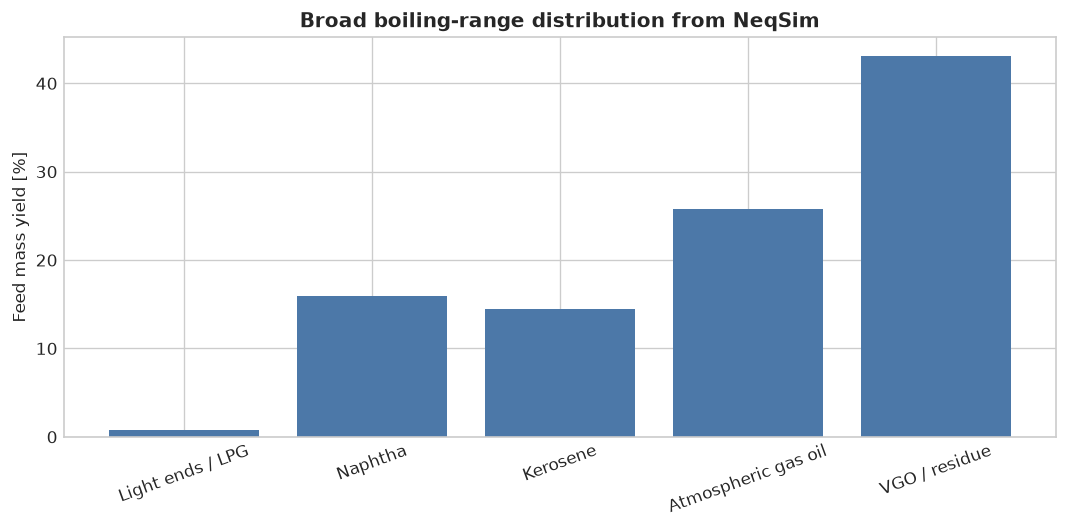

In [6]:
def cut_name(boiling_point_c):
    if boiling_point_c < 30.0:
        return "Light ends / LPG"
    if boiling_point_c < 180.0:
        return "Naphtha"
    if boiling_point_c < 270.0:
        return "Kerosene"
    if boiling_point_c < 370.0:
        return "Atmospheric gas oil"
    return "VGO / residue"


assay_records = []
for component_index in range(crude.getNumberOfComponents()):
    component = crude.getComponent(component_index)
    boiling_point_c = component.getNormalBoilingPoint() - 273.15
    assay_records.append(
        {
            "Component": str(component.getComponentName()),
            "Mole fraction": component.getz(),
            "Molar mass [kg/mol]": component.getMolarMass(),
            "Normal boiling point [C]": boiling_point_c,
            "Broad cut": cut_name(boiling_point_c),
        }
    )
assay_table = pd.DataFrame(assay_records)
mass_basis = assay_table["Mole fraction"] * assay_table["Molar mass [kg/mol]"]
assay_table["Mass fraction"] = mass_basis / mass_basis.sum()
cut_order = [
    "Light ends / LPG",
    "Naphtha",
    "Kerosene",
    "Atmospheric gas oil",
    "VGO / residue",
]
cut_yields = (
    assay_table.groupby("Broad cut")["Mass fraction"]
    .sum()
    .reindex(cut_order, fill_value=0.0)
)
display(assay_table.round(5))
display((100.0 * cut_yields).rename("Feed mass yield [%]").to_frame().round(2))

figure, axis = plt.subplots(figsize=(9, 4.5))
axis.bar(cut_order, 100.0 * cut_yields.to_numpy(), color="#4C78A8")
axis.set_ylabel("Feed mass yield [%]")
axis.set_title("Broad boiling-range distribution from NeqSim")
axis.tick_params(axis="x", rotation=20)
figure.tight_layout()
plt.show()

## 5. Quantity determination

The observed vessel or shore-tank volume is corrected to the contract reference
temperature, then reduced for basic sediment and water (BS&W):

$$V_{\mathrm{net,15}}=V_{\mathrm{obs}}C_{\mathrm{TL}}(1-f_{\mathrm{BS\&W}})$$

Actual custody transfer follows the specified petroleum measurement standards, calibrated
instruments, sampling, vessel-experience factor where applicable, and inspector procedures.
The linear thermal-expansion screen below is educational, not a replacement for API/ASTM
volume-correction tables.

In [7]:
BARREL_TO_M3 = 0.158987294928
observed_volume_bbl = 610_000.0
observed_temperature_c = 35.0
reference_temperature_c = 15.0
thermal_expansion_per_c = 0.00075
bsw_fraction = 0.0035
temperature_factor = 1.0 / (
    1.0
    + thermal_expansion_per_c
    * (observed_temperature_c - reference_temperature_c)
)
gross_standard_bbl = observed_volume_bbl * temperature_factor
net_standard_bbl = gross_standard_bbl * (1.0 - bsw_fraction)
net_standard_m3 = net_standard_bbl * BARREL_TO_M3
net_mass_tonnes = net_standard_m3 * density_kg_m3 / 1000.0
quantity_table = pd.Series(
    {
        "Observed volume [bbl]": observed_volume_bbl,
        "Observed temperature [C]": observed_temperature_c,
        "Temperature correction factor": temperature_factor,
        "Gross standard volume [bbl at 15 C]": gross_standard_bbl,
        "BS&W [vol%]": 100.0 * bsw_fraction,
        "Net standard quantity [bbl]": net_standard_bbl,
        "Net mass [tonnes]": net_mass_tonnes,
    },
    name="Synthetic custody-transfer screen",
)
display(quantity_table.to_frame().round(3))

,Synthetic custody-transfer screen
Observed volume [bbl],610000.000
Observed temperature [C],35.000
Temperature correction factor,0.985
Gross standard volume [bbl at 15 C],600985.222
BS&W [vol%],0.350
Net standard quantity [bbl],598881.773
Net mass [tonnes],82688.155


## 6. Benchmark pricing and invoice

A common commercial structure is

$$P_{\mathrm{cargo}}=P_{\mathrm{benchmark,QP}}+D_{\mathrm{grade}}+A_{\mathrm{quality}}+A_{\mathrm{location}}$$

The quotation-period average and every differential must follow the contract. A price
reporting agency assessment is not interchangeable with a futures settlement merely because
both are called Brent. The example uses synthetic daily values and a 10-day average.

,Synthetic pricing statement
Benchmark QP average [USD/bbl],81.084
Grade differential [USD/bbl],-1.250
Quality adjustment [USD/bbl],-0.350
Location adjustment [USD/bbl],0.200
Final cargo price [USD/bbl],79.684
Provisional invoice [million USD],45.515
Final invoice [million USD],47.722
Final true-up [million USD],2.206


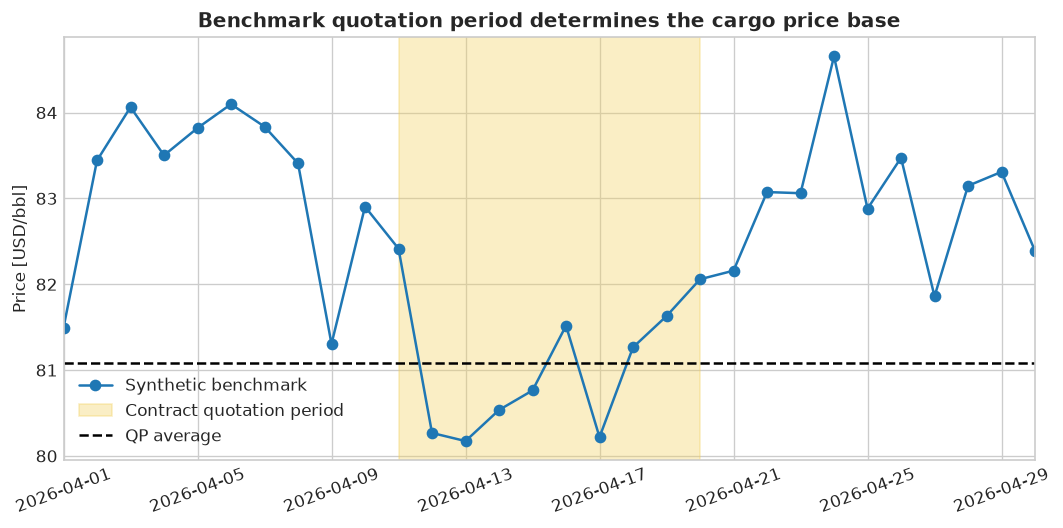

In [8]:
rng = np.random.default_rng(20260805)
pricing_dates = pd.date_range("2026-04-01", periods=30, freq="D")
benchmark_usd_bbl = (
    82.0
    + 1.7 * np.sin(np.linspace(0.0, 3.0 * np.pi, 30))
    + rng.normal(0.0, 0.65, 30)
)
benchmark_series = pd.Series(benchmark_usd_bbl, index=pricing_dates)
quotation_period = benchmark_series.iloc[10:20]
benchmark_average = quotation_period.mean()
GRADE_DIFFERENTIAL_USD_BBL = -1.25
QUALITY_ADJUSTMENT_USD_BBL = -0.35
LOCATION_ADJUSTMENT_USD_BBL = 0.20
cargo_price_usd_bbl = (
    benchmark_average
    + GRADE_DIFFERENTIAL_USD_BBL
    + QUALITY_ADJUSTMENT_USD_BBL
    + LOCATION_ADJUSTMENT_USD_BBL
)
final_invoice_usd = cargo_price_usd_bbl * net_standard_bbl
provisional_price_usd_bbl = 80.0
provisional_quantity_bbl = 0.95 * net_standard_bbl
provisional_invoice_usd = provisional_price_usd_bbl * provisional_quantity_bbl
final_true_up_usd = final_invoice_usd - provisional_invoice_usd

pricing_table = pd.Series(
    {
        "Benchmark QP average [USD/bbl]": benchmark_average,
        "Grade differential [USD/bbl]": GRADE_DIFFERENTIAL_USD_BBL,
        "Quality adjustment [USD/bbl]": QUALITY_ADJUSTMENT_USD_BBL,
        "Location adjustment [USD/bbl]": LOCATION_ADJUSTMENT_USD_BBL,
        "Final cargo price [USD/bbl]": cargo_price_usd_bbl,
        "Provisional invoice [million USD]": provisional_invoice_usd / 1.0e6,
        "Final invoice [million USD]": final_invoice_usd / 1.0e6,
        "Final true-up [million USD]": final_true_up_usd / 1.0e6,
    },
    name="Synthetic pricing statement",
)
display(pricing_table.to_frame().round(3))

figure, axis = plt.subplots(figsize=(9, 4.5))
axis.plot(benchmark_series.index, benchmark_series, marker="o", label="Synthetic benchmark")
axis.axvspan(
    quotation_period.index.min(),
    quotation_period.index.max(),
    color="#F2CF5B",
    alpha=0.35,
    label="Contract quotation period",
)
axis.axhline(benchmark_average, color="black", linestyle="--", label="QP average")
axis.set_ylabel("Price [USD/bbl]")
axis.set_title("Benchmark quotation period determines the cargo price base")
axis.set_xlim(pricing_dates.min(), pricing_dates.max())
axis.tick_params(axis="x", rotation=20)
axis.legend()
figure.tight_layout()
plt.show()

## 7. Terminal, pipeline, tanker, and demurrage

The terminal and transport chain sells capacity and services, not the crude benchmark.
The seller and buyer allocate freight, insurance, risk, inspection, and demurrage under
their contract. A laycan is an arrival/loading window; laytime is allowed loading time;
demurrage is a pre-agreed daily amount for qualifying excess time.

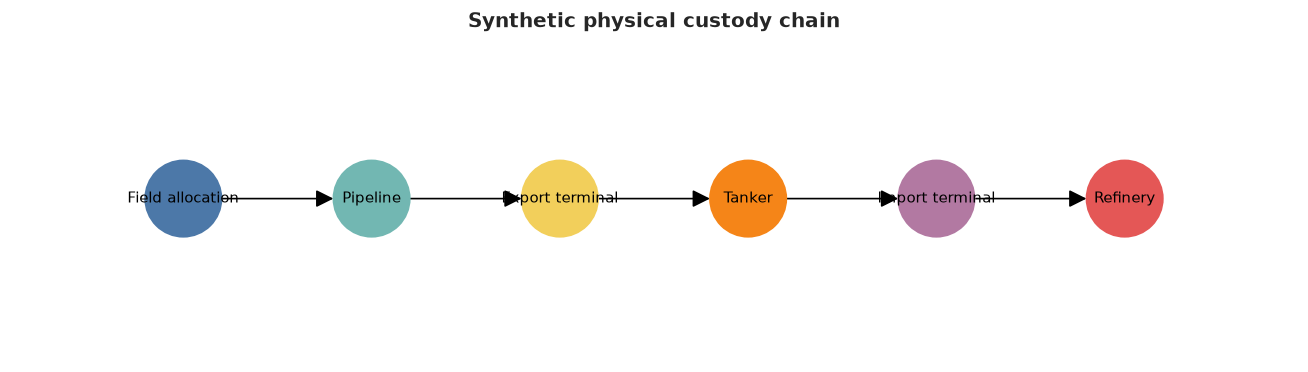

,Illustrative logistics ledger
Pipeline and export terminal [USD/bbl],1.200
Ocean freight [USD/bbl],1.100
Insurance and inspection [USD/bbl],0.080
Allowed laytime [h],36.000
Actual laytime [h],44.000
Demurrage [USD],15000.000
Demurrage [USD/bbl],0.025


In [9]:
logistics_graph = nx.DiGraph()
logistics_graph.add_edges_from(
    [
        ("Field allocation", "Pipeline"),
        ("Pipeline", "Export terminal"),
        ("Export terminal", "Tanker"),
        ("Tanker", "Import terminal"),
        ("Import terminal", "Refinery"),
    ]
)
positions = {node: (index, 0.0) for index, node in enumerate(logistics_graph.nodes)}
figure, axis = plt.subplots(figsize=(11, 3.2))
nx.draw_networkx(
    logistics_graph,
    pos=positions,
    node_color=["#4C78A8", "#72B7B2", "#F2CF5B", "#F58518", "#B279A2", "#E45756"],
    node_size=2100,
    font_size=9,
    arrowsize=22,
    ax=axis,
)
axis.set_title("Synthetic physical custody chain")
axis.margins(x=0.12, y=0.35)
axis.axis("off")
figure.tight_layout()
plt.show()

allowed_laytime_hours = 36.0
actual_laytime_hours = 44.0
demurrage_rate_usd_day = 45_000.0
excess_laytime_hours = max(actual_laytime_hours - allowed_laytime_hours, 0.0)
demurrage_usd = excess_laytime_hours / 24.0 * demurrage_rate_usd_day
logistics_costs = pd.Series(
    {
        "Pipeline and export terminal [USD/bbl]": 1.20,
        "Ocean freight [USD/bbl]": 1.10,
        "Insurance and inspection [USD/bbl]": 0.08,
        "Allowed laytime [h]": allowed_laytime_hours,
        "Actual laytime [h]": actual_laytime_hours,
        "Demurrage [USD]": demurrage_usd,
        "Demurrage [USD/bbl]": demurrage_usd / net_standard_bbl,
    },
    name="Illustrative logistics ledger",
)
display(logistics_costs.to_frame().round(4))

## 8. Refinery-buyer value and producer netback

The buyer compares delivered crude cost with marginal product value after yields, product
prices, energy, hydrogen, catalysts, emissions, capacity constraints, and blending. The
simple gross-product-worth screen below uses broad NeqSim feed fractions, not calibrated
unit yields. The separate refinery notebook develops the physical process layer.

In [10]:
product_value_usd_bbl_feed = pd.Series(
    {
        "Light ends / LPG": 72.0,
        "Naphtha": 84.0,
        "Kerosene": 101.0,
        "Atmospheric gas oil": 96.0,
        "VGO / residue": 61.0,
    }
)
value_table = pd.DataFrame(
    {
        "Mass yield": cut_yields,
        "Value coefficient [USD/bbl feed]": product_value_usd_bbl_feed,
    }
)
value_table["Contribution [USD/bbl feed]"] = (
    value_table["Mass yield"]
    * value_table["Value coefficient [USD/bbl feed]"]
)
gross_product_worth = value_table["Contribution [USD/bbl feed]"].sum()
REFINING_VARIABLE_COST_USD_BBL = 5.50
IMPORT_LOGISTICS_USD_BBL = 1.18
buyer_margin_usd_bbl = (
    gross_product_worth
    - REFINING_VARIABLE_COST_USD_BBL
    - IMPORT_LOGISTICS_USD_BBL
    - cargo_price_usd_bbl
)
PRODUCER_COST_USD_BBL = 18.0
EXPORT_LOGISTICS_USD_BBL = 1.20
producer_netback_usd_bbl = (
    cargo_price_usd_bbl
    - EXPORT_LOGISTICS_USD_BBL
    - PRODUCER_COST_USD_BBL
)
display(value_table.round(3))
economics = pd.Series(
    {
        "Gross product worth [USD/bbl feed]": gross_product_worth,
        "Buyer refining variable cost [USD/bbl]": REFINING_VARIABLE_COST_USD_BBL,
        "Buyer import logistics [USD/bbl]": IMPORT_LOGISTICS_USD_BBL,
        "Buyer crude price [USD/bbl]": cargo_price_usd_bbl,
        "Buyer screening margin [USD/bbl]": buyer_margin_usd_bbl,
        "Producer upstream and operating cost [USD/bbl]": PRODUCER_COST_USD_BBL,
        "Producer export logistics [USD/bbl]": EXPORT_LOGISTICS_USD_BBL,
        "Producer netback [USD/bbl]": producer_netback_usd_bbl,
    },
    name="Buyer and producer screen",
)
display(economics.to_frame().round(3))

,Mass yield,Value coefficient [USD/bbl feed],Contribution [USD/bbl feed]
Light ends / LPG,0.007,72.0,0.517
Naphtha,0.160,84.0,13.413
Kerosene,0.144,101.0,14.578
Atmospheric gas oil,0.258,96.0,24.783
VGO / residue,0.431,61.0,26.270


,Buyer and producer screen
Gross product worth [USD/bbl feed],79.560
Buyer refining variable cost [USD/bbl],5.500
Buyer import logistics [USD/bbl],1.180
Buyer crude price [USD/bbl],79.684
Buyer screening margin [USD/bbl],-6.804
Producer upstream and operating cost [USD/bbl],18.000
Producer export logistics [USD/bbl],1.200
Producer netback [USD/bbl],60.484


The negative buyer screen means this illustrative cargo price exceeds broad-cut value after
the stated variable costs. It is a commercial decision signal under these assumptions—not a
prediction of refinery accounting profit. A buyer could reject the cargo, seek a larger
discount, change the crude slate, or value conversion and blending options not represented here.

## 9. Cash reconciliation

The buyer's delivered cost is allocated to seller receipt, export logistics, ocean freight,
insurance/inspection, and demurrage. Upstream production cost is internal to producer
netback and should not be added again to the buyer invoice.

In [11]:
freight_usd_bbl = 1.10
insurance_usd_bbl = 0.08
demurrage_usd_bbl = demurrage_usd / net_standard_bbl
buyer_delivered_cost_usd_bbl = (
    cargo_price_usd_bbl
    + freight_usd_bbl
    + insurance_usd_bbl
    + demurrage_usd_bbl
)
cash_ledger = pd.DataFrame(
    {
        "Actor": [
            "Refinery buyer",
            "Producer / seller",
            "Ocean carrier",
            "Insurance and inspection",
            "Demurrage recipient",
        ],
        "Cash [USD/bbl]": [
            -buyer_delivered_cost_usd_bbl,
            cargo_price_usd_bbl,
            freight_usd_bbl,
            insurance_usd_bbl,
            demurrage_usd_bbl,
        ],
    }
)
cash_closure = cash_ledger["Cash [USD/bbl]"].sum()
display(cash_ledger.round(4))
print(f"External cargo cash closure: {cash_closure:.8f} USD/bbl")

External cargo cash closure: 0.00000000 USD/bbl


,Actor,Cash [USD/bbl]
0,Refinery buyer,-80.8894
1,Producer / seller,79.6843
2,Ocean carrier,1.1000
3,Insurance and inspection,0.0800
4,Demurrage recipient,0.0250


## 10. Connections, limitations, and next steps

- Continue with [NeqSim oil-refinery simulation](../process/neqsim_oil_refinery_simulation_foundation.ipynb)
  for preheat, flashes, fractionation screening, yields, energy, and constraints.
- Connect to [oil and gas production optimisation](../production/oilgasproductionoptimization.ipynb)
  for production and facility decisions.
- Use [multistage oil stabilisation](../process/Simulationofanoilstabilizationprocess.ipynb)
  for export crude volatility and recovery.
- Use [oil-pipeline and terminal transport](../transport/) notebooks for hydraulic detail.

This notebook does not model full crude assays, sulfur species, TAN, metals, salt, fouling,
asphaltenes, blending, refinery conversion units, tax, sanctions, credit, charter-party
law, or actual Incoterms clauses. Commercial and measurement standards must be taken from
the governing contract and licensed publications. The explicit oil-phase density fallback
documents [NeqSim issue #2828](https://github.com/equinor/neqsim/issues/2828) and remains
compatible with [the upstream fix](https://github.com/equinor/neqsim/pull/2829).

In [12]:
checks = {
    "NeqSim oil class loaded from source JAR": str(NEQSIM_JAR) in oil_class_source,
    "Assay closes": math.isclose(assay_sum, 1.0, abs_tol=1.0e-12),
    "Density plausible": 750.0 < density_kg_m3 < 950.0,
    "API gravity plausible": 15.0 < api_gravity < 50.0,
    "Oil phase identified for custody density": bool(oil_phase_indices),
    "RVP positive": rvp_bara > 0.0,
    "Cut yields close": math.isclose(cut_yields.sum(), 1.0, abs_tol=1.0e-10),
    "Temperature correction reduces hot volume": temperature_factor < 1.0,
    "Net quantity below observed": net_standard_bbl < observed_volume_bbl,
    "Final invoice positive": final_invoice_usd > 0.0,
    "Demurrage positive after excess time": demurrage_usd > 0.0,
    "Buyer margin finite": math.isfinite(buyer_margin_usd_bbl),
    "Cargo cash ledger closes": abs(cash_closure) < 1.0e-10,
}
validation_table = pd.DataFrame(
    {"Check": list(checks), "Passed": list(checks.values())}
)
display(validation_table)
assert all(checks.values()), [name for name, passed in checks.items() if not passed]
print(f"All {len(checks)} named checks passed.")

All 13 named checks passed.


,Check,Passed
0,NeqSim oil class loaded from source JAR,True
1,Assay closes,True
2,Density plausible,True
3,API gravity plausible,True
4,Oil phase identified for custody density,True
5,RVP positive,True
6,Cut yields close,True
7,Temperature correction reduces hot volume,True
8,Net quantity below observed,True
9,Final invoice positive,True


In [13]:
provenance = pd.DataFrame(
    {
        "Component": [
            "NeqSim Java commit",
            "NeqSim JAR SHA-256",
            "Python",
            "NumPy",
            "pandas",
            "Market and assay data",
        ],
        "Identity": [
            NEQSIM_COMMIT,
            NEQSIM_JAR_SHA256,
            platform.python_version(),
            np.__version__,
            pd.__version__,
            "synthetic teaching snapshot dated 2026-08-05",
        ],
    }
)
display(provenance)
print(
    json.dumps(
        {
            "api_gravity": api_gravity,
            "net_cargo_bbl": net_standard_bbl,
            "cargo_price_usd_bbl": cargo_price_usd_bbl,
            "buyer_margin_usd_bbl": buyer_margin_usd_bbl,
            "producer_netback_usd_bbl": producer_netback_usd_bbl,
            "checks_passed": int(sum(checks.values())),
        },
        indent=2,
    )
)

{
  "api_gravity": 31.275522282294617,
  "net_cargo_bbl": 598881.7733990148,
  "cargo_price_usd_bbl": 79.68434922709021,
  "buyer_margin_usd_bbl": -6.803916335948372,
  "producer_netback_usd_bbl": 60.484349227090206,
  "checks_passed": 13
}


,Component,Identity
0,NeqSim Java commit,7ae08253b45180045a99a700314f23c9a7001b3c
1,NeqSim JAR SHA-256,d1bdf734644537f2304d17e2e354008c48f189858a9055...
2,Python,3.12.13
3,NumPy,2.5.1
4,pandas,3.0.5
5,Market and assay data,synthetic teaching snapshot dated 2026-08-05


## Primary references and suggested exercises

- [Incoterms rules, International Chamber of Commerce](https://iccwbo.org/business-solutions/incoterms-rules/)
- [Eurostat international trade in energy products](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=EU_trade_in_energy_products_-_latest_developments)
- [UN Comtrade API](https://comtradeapi.un.org/)
- [US EIA Open Data](https://www.eia.gov/opendata/)
- [World Bank commodity markets](https://www.worldbank.org/en/research/commodity-markets)
- [Norwegian Offshore Directorate production data](https://www.sodir.no/en/whats-new/publications/reports/)

Exercises: replace synthetic benchmark data with a licensed snapshot; compare FOB and CIF
cashflows; add quantity tolerance and optionality; value sulfur and API sensitivities using
several assays; include freight scenarios and arrival delays; connect each cargo identity to
a refinery LP and producer entitlement forecast.